In [ ]:
!pwd
%cd /media/laptq/data/workspace/hello-gen-ai

/media/laptq/data/workspace/hello-gen-ai/notebooks


/media/laptq/data/workspace/hello-gen-ai


/media/laptq/data/workspace/hello-gen-ai/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
BATCHSIZE = 128
STEP_SIZE = 200
LR = 0.001
EPOCHS = 30
DEVICE = 'cuda:0'
N_HIDDENS = 8
N_LABELS = 10

In [3]:
device = torch.device(DEVICE)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

trainset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
trainloader = DataLoader(
    trainset,
    batch_size=BATCHSIZE,
    shuffle=True,
    num_workers=2
)

testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
testloader = DataLoader(
    testset,
    batch_size=BATCHSIZE,
    shuffle=False,
    num_workers=2
)

classes = [str(i) for i in range(10)]


# print image shape
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(images.shape)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.10MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.54MB/s]


torch.Size([128, 1, 28, 28])


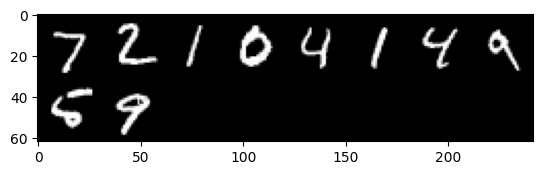

7     2     1     0     4     1     4     9     5     9    


In [4]:
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(testloader)
images, labels = next(dataiter)

n_show = 10
imshow(torchvision.utils.make_grid(images[:n_show]))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(min(n_show, BATCHSIZE))))

## AE

In [9]:
class Encoder(nn.Module):

    def __init__(
            self,
            **kwargs
    ):
        super(Encoder, self).__init__()

        n_hiddens = kwargs['n_hiddens']

        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, n_hiddens)


    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))

        return x


class Decoder(nn.Module):

    def __init__(
            self,
            **kwargs
    ):
        super(Decoder, self).__init__()

        n_hiddens = kwargs['n_hiddens']

        self.fc1 = nn.Linear(n_hiddens, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 256)
        self.fc4 = nn.Linear(256, 28*28)


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = F.sigmoid(x)
        x = torch.reshape(x, (-1, 1, 28, 28))

        return x


class AE(nn.Module):

        def __init__(
                self,
                **kwargs
        ):
            super(AE, self).__init__()

            self.n_hiddens = kwargs['n_hiddens']

            self.encoder = Encoder(n_hiddens=self.n_hiddens)
            self.decoder = Decoder(n_hiddens=self.n_hiddens)


        def forward(self, x):
            encoded = self.encoder(x)
            decoded = self.decoder(encoded)

            return encoded, decoded


net_ae = AE(
    n_hiddens=N_HIDDENS
)

net_ae.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(     # use Adam instead of SGD, unsure why using SGD stuck at local minimum
    net_ae.parameters(),
    lr=LR,
)

net_ae(torch.randn(1, 1, 28, 28).to(device))

net_ae

AE(
  (encoder): Encoder(
    (fc1): Linear(in_features=784, out_features=256, bias=True)
    (fc2): Linear(in_features=256, out_features=128, bias=True)
    (fc3): Linear(in_features=128, out_features=64, bias=True)
    (fc4): Linear(in_features=64, out_features=8, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=8, out_features=64, bias=True)
    (fc2): Linear(in_features=64, out_features=128, bias=True)
    (fc3): Linear(in_features=128, out_features=256, bias=True)
    (fc4): Linear(in_features=256, out_features=784, bias=True)
  )
)

In [10]:
net_ae.train()

for epoch in range(EPOCHS):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, _ = data
        inputs = inputs.to(device)
        optimizer.zero_grad()
        _, decoded = net_ae(inputs)
        loss = criterion(decoded, inputs)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % STEP_SIZE == (STEP_SIZE - 1):
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / STEP_SIZE:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,   200] loss: 0.075
[1,   400] loss: 0.053
[2,   200] loss: 0.043
[2,   400] loss: 0.037
[3,   200] loss: 0.031
[3,   400] loss: 0.029
[4,   200] loss: 0.028
[4,   400] loss: 0.027
[5,   200] loss: 0.026
[5,   400] loss: 0.025
[6,   200] loss: 0.024
[6,   400] loss: 0.023
[7,   200] loss: 0.023
[7,   400] loss: 0.023
[8,   200] loss: 0.022
[8,   400] loss: 0.022
[9,   200] loss: 0.021
[9,   400] loss: 0.021
[10,   200] loss: 0.021
[10,   400] loss: 0.021
[11,   200] loss: 0.020
[11,   400] loss: 0.020
[12,   200] loss: 0.020
[12,   400] loss: 0.020
[13,   200] loss: 0.020
[13,   400] loss: 0.020
[14,   200] loss: 0.019
[14,   400] loss: 0.019
[15,   200] loss: 0.019
[15,   400] loss: 0.019
Finished Training


In [11]:
mae = 0
with torch.no_grad():
    for data in testloader:
        images, _ = data
        images = images.to(device)
        _, decoded = net_ae(images)
        mae += torch.mean(torch.abs(decoded - images)).item()

print(f'MAE of the network on the test images: {mae / len(testloader)}')

MAE of the network on the test images: 0.05220952785656422


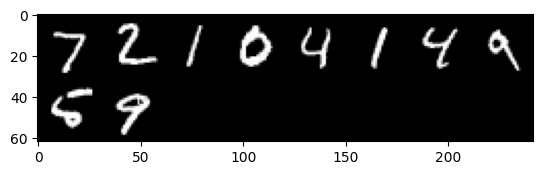

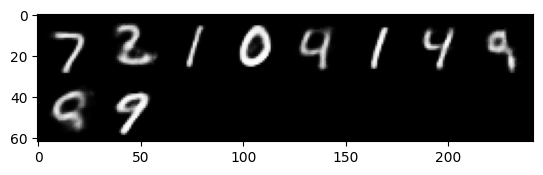

In [12]:
dataiter = iter(testloader)
images, _ = next(dataiter)
with torch.no_grad():
    images = images.to(device)
    _, decoded = net_ae(images)

n_show = 10
imshow(torchvision.utils.make_grid(images.cpu()[:n_show]))
imshow(torchvision.utils.make_grid(decoded.cpu()[:n_show]))

## VAE

In [20]:
class VAE(AE):

    def __init__(
            self,
            **kwargs
    ):
        super(VAE, self).__init__(**kwargs)

        self.mu = nn.Linear(self.n_hiddens, self.n_hiddens)
        self.logvar = nn.Linear(self.n_hiddens, self.n_hiddens)


    def forward(self, x):
        encoded = self.encoder(x)

        mu = self.mu(encoded)
        logvar = self.logvar(encoded)

        # reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        encoded = mu + eps * std

        decoded = self.decoder(encoded)

        return encoded, decoded, mu, logvar


    def generate(self, noise):
        with torch.no_grad():
            decoded = self.decoder(noise)

        return decoded


net_vae = VAE(
    n_hiddens=N_HIDDENS
)

net_vae.to(device)

def loss_fn(
        **kwargs
):
    inputs = kwargs['inputs']
    decoded = kwargs['decoded']
    mu = kwargs['mu']
    logvar = kwargs['logvar']
    target_mu = kwargs['targer_mu']
    target_logvar = kwargs['target_logvar']


    loss_rec = nn.MSELoss(
        reduction='sum'     # sum instead of mean, because KLD is also sum
    )(decoded, inputs)
    loss_kl = 0.5 * torch.sum(target_logvar - logvar + (logvar.exp() + (mu - target_mu).pow(2)) / target_logvar.exp() - 1)

    return loss_rec + 3 * loss_kl

optimizer = optim.Adam(
    net_vae.parameters(),
    lr=LR,
)

[1,   200] loss: 6194.167
[1,   400] loss: 6195.224


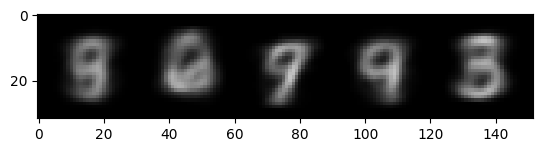

[2,   200] loss: 6143.468
[2,   400] loss: 6112.178


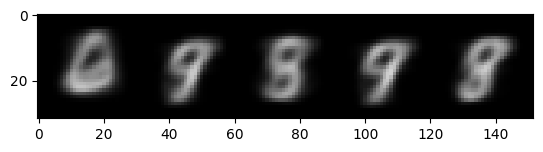

[3,   200] loss: 6051.607
[3,   400] loss: 6003.408


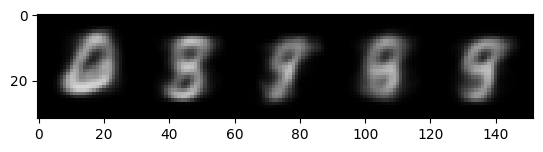

[4,   200] loss: 5982.738
[4,   400] loss: 5981.999


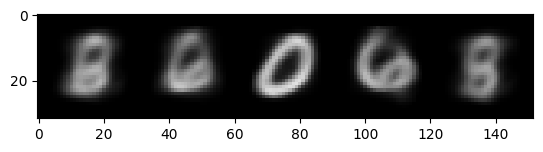

[5,   200] loss: 5944.293
[5,   400] loss: 5961.170


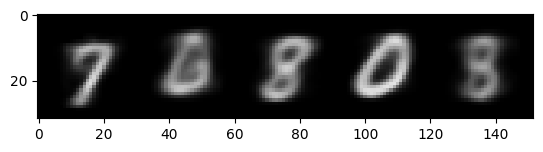

[6,   200] loss: 5923.665
[6,   400] loss: 5912.413


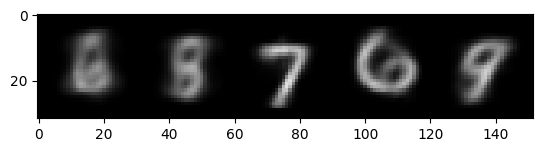

[7,   200] loss: 5900.157
[7,   400] loss: 5892.210


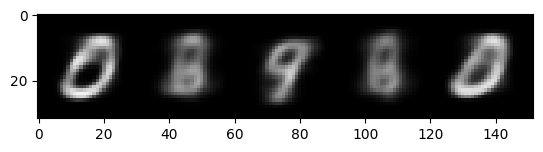

[8,   200] loss: 5878.615
[8,   400] loss: 5870.805


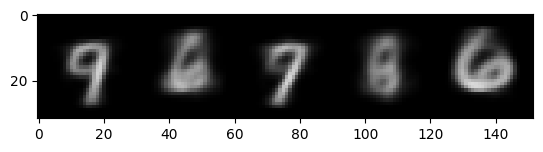

[9,   200] loss: 5882.994
[9,   400] loss: 5896.171


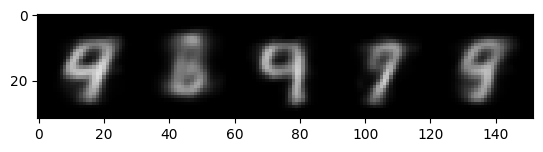

[10,   200] loss: 5865.272
[10,   400] loss: 5855.100


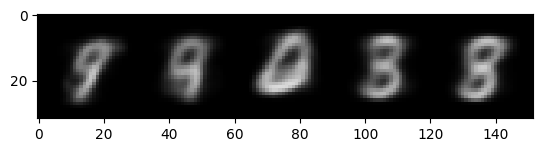

[11,   200] loss: 5845.965
[11,   400] loss: 5833.173


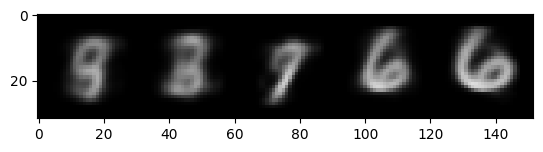

[12,   200] loss: 5832.953
[12,   400] loss: 5813.500


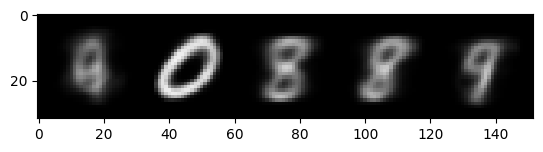

[13,   200] loss: 5815.689
[13,   400] loss: 5802.364


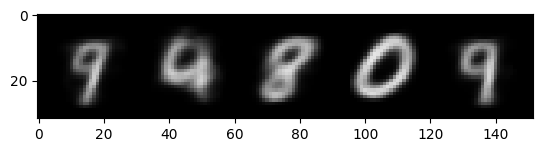

[14,   200] loss: 5810.839
[14,   400] loss: 5839.178


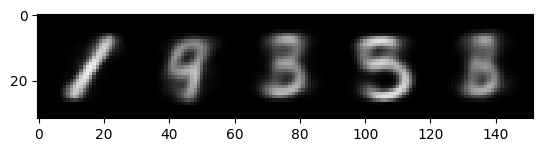

[15,   200] loss: 5796.189
[15,   400] loss: 5804.075


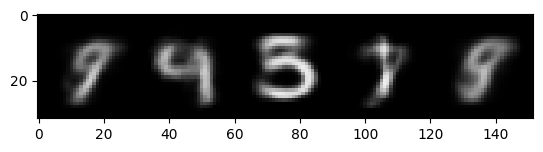

Finished Training


In [63]:
for epoch in range(EPOCHS):

    net_vae.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, _ = data
        inputs = inputs.to(device)
        optimizer.zero_grad()
        _, decoded, mu, logvar = net_vae(inputs)
        loss = loss_fn(
            inputs=inputs,
            decoded=decoded,
            mu=mu,
            logvar=logvar,
            targer_mu=torch.tensor(5, device=DEVICE),       # try setting mean to 5 instead of 0
            target_logvar=torch.tensor(0, device=DEVICE),
        )
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % STEP_SIZE == (STEP_SIZE - 1):
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / STEP_SIZE:.3f}')
            running_loss = 0.0

    net_vae.eval()
    with torch.no_grad():
        noise = torch.randn(5, N_HIDDENS).to(device) + 5
        img_gen = net_vae.generate(noise)
        img_gen = img_gen.cpu()
        imshow(torchvision.utils.make_grid(img_gen))

print('Finished Training')

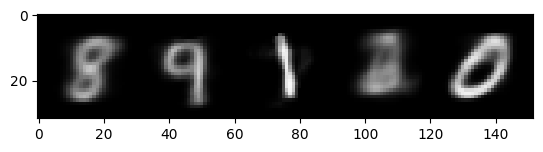

In [69]:
with torch.no_grad():
    noise = torch.randn(5, N_HIDDENS).to(device) + 5    # mean is 5
    img_gen = net_vae.generate(noise)
    img_gen = img_gen.cpu()
    imshow(torchvision.utils.make_grid(img_gen))

## Conditional VAE using different mean instead of label flag

In [120]:
class CVAE(VAE):

    def __init__(
            self,
            **kwargs
    ):
        super(CVAE, self).__init__(**kwargs)

        self.n_labels = kwargs['n_labels']


    def forward(self, x, y):
        encoded = self.encoder(x)

        mu = self.mu(encoded)
        logvar = self.logvar(encoded)

        # reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        encoded = mu + eps * std

        decoded = self.decoder(encoded)

        return encoded, decoded, mu, logvar


    def generate(self, noise, cond):
        with torch.no_grad():
            decoded = self.decoder(noise)

        return decoded


net_cvae = CVAE(
    n_hiddens=N_HIDDENS,
    n_labels=N_LABELS,
)

net_cvae.to(device)

optimizer = optim.Adam(
    net_cvae.parameters(),
    lr=LR,
)

In [121]:
# I will use mean 1, 2, 3... for class 1, 2, 3
STD = 0.2   # so, I will choose std to be 0.2 so that 3*std (i.e. covering 99.7% of each class) will not overlap

[1,   200] loss: 9074.394
[1,   400] loss: 9676.963


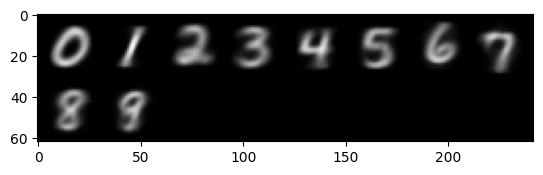

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[2,   200] loss: 9289.136
[2,   400] loss: 9977.882


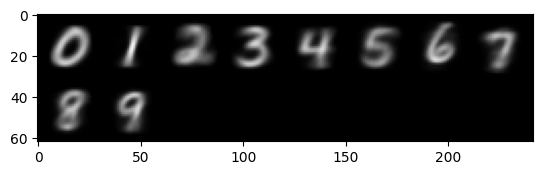

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[3,   200] loss: 8584.869
[3,   400] loss: 9755.200


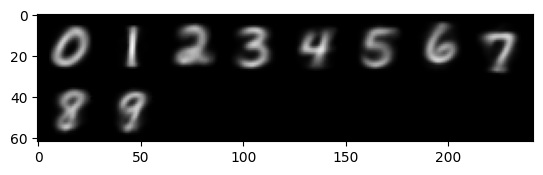

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[4,   200] loss: 9175.733
[4,   400] loss: 9036.625


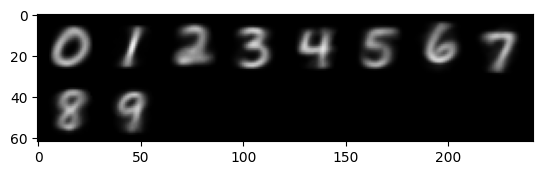

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[5,   200] loss: 9058.692
[5,   400] loss: 8128.995


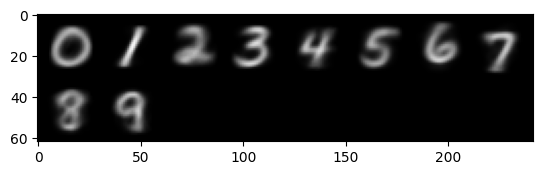

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[6,   200] loss: 8336.345
[6,   400] loss: 7841.768


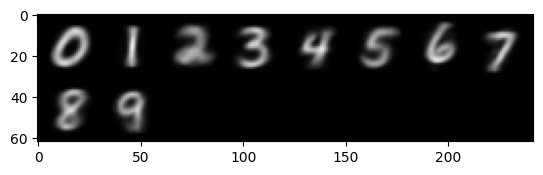

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[7,   200] loss: 7256.520
[7,   400] loss: 7548.065


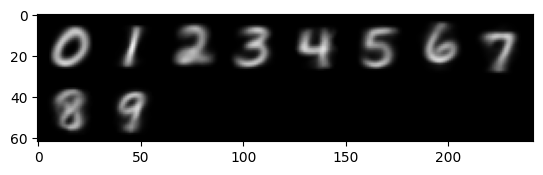

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[8,   200] loss: 8349.498
[8,   400] loss: 9162.075


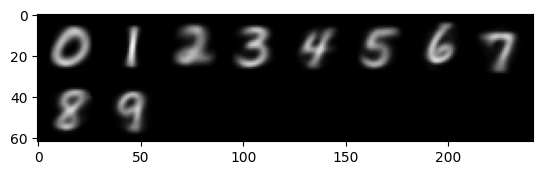

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[9,   200] loss: 7941.652
[9,   400] loss: 8810.561


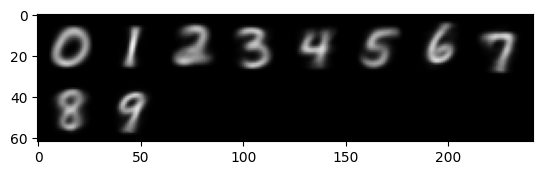

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[10,   200] loss: 7232.648
[10,   400] loss: 7128.974


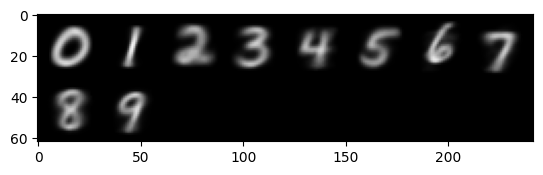

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[11,   200] loss: 6748.523
[11,   400] loss: 6523.742


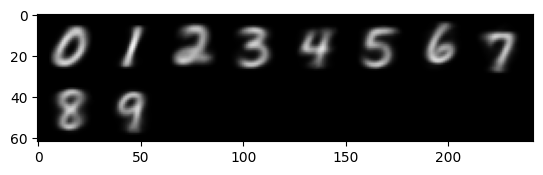

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[12,   200] loss: 6778.672
[12,   400] loss: 9263.159


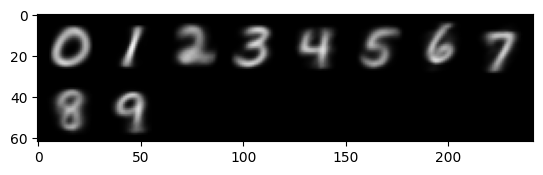

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[13,   200] loss: 9445.871
[13,   400] loss: 8979.290


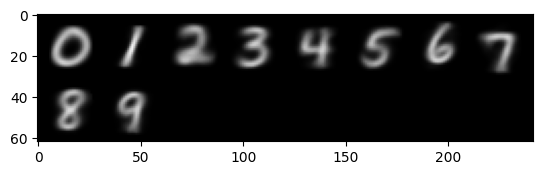

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[14,   200] loss: 8227.228
[14,   400] loss: 7237.942


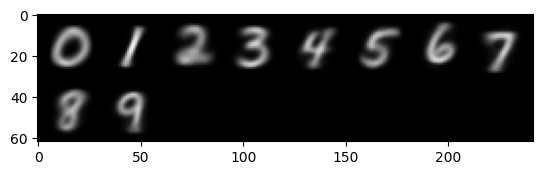

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[15,   200] loss: 6676.130
[15,   400] loss: 6895.950


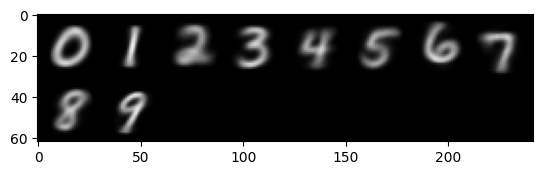

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Finished Training


In [126]:

for epoch in range(EPOCHS):

    net_cvae.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs = inputs.to(device)
        onehot = F.one_hot(labels, num_classes=N_LABELS).float().to(device)
        optimizer.zero_grad()
        _, decoded, mu, logvar = net_cvae(inputs, onehot)

        target_mu = labels.repeat(N_HIDDENS, 1).T.to(device)        # using mean 1, 2, 3... for class 1, 2, 3,
        target_logvar = torch.tensor(np.log(STD**2), device=DEVICE)

        loss = loss_fn(
            inputs=inputs,
            decoded=decoded,
            mu=mu,
            logvar=logvar,
            targer_mu=target_mu,
            target_logvar=target_logvar,
        )
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % STEP_SIZE == (STEP_SIZE - 1):
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / STEP_SIZE:.3f}')
            running_loss = 0.0

    net_cvae.eval()
    n_examples = N_LABELS
    with torch.no_grad():
        noise = torch.randn(n_examples, N_HIDDENS).to(device) * STD + torch.arange(n_examples).repeat(N_HIDDENS, 1).T.to(device)    # create a noise that fall within the N(mean, std**2)
        labels = torch.arange(n_examples)
        cond = F.one_hot(labels, num_classes=N_LABELS).float().to(device)
        img_gen = net_cvae.generate(noise, cond)
        img_gen = img_gen.cpu()
        imshow(torchvision.utils.make_grid(img_gen))
        print(labels)

print('Finished Training')

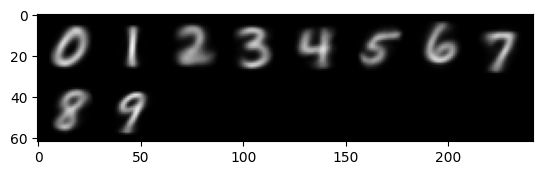

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [138]:
n_examples = 10
with torch.no_grad():
    noise = torch.randn(n_examples, N_HIDDENS).to(device) * STD + torch.arange(n_examples).repeat(N_HIDDENS, 1).T.to(device)
    labels = torch.arange(n_examples)
    cond = F.one_hot(labels, num_classes=N_LABELS).float().to(device)
    img_gen = net_cvae.generate(noise, cond)
    img_gen = img_gen.cpu()
    imshow(torchvision.utils.make_grid(img_gen))
    print(labels)

# References

1. https://medium.com/@sofeikov/implementing-variational-autoencoders-from-scratch-533782d8eb95
2. https://medium.com/@sofeikov/implementing-conditional-variational-auto-encoders-cvae-from-scratch-29fcbb8cb08f